# Crossing Flows: I-CFM vs OT-CFM on a Bimodal-to-Bimodal Transport

## The core question: does the *coupling* between source and target samples matter?

The CFM loss pairs each source sample $x_0 \sim p_0$ with a target sample $x_1 \sim p_1$ and regresses against the straight-line vector field $u_t(x|x_0,x_1) = x_1 - x_0$.

If we pick these pairs **independently** (I-CFM), a source particle at $x_0 = -3$ is equally likely to be paired with the left mode ($x_1 \approx -1$) *or* the right mode ($x_1 \approx +1$). The resulting conditional vector fields **point in opposite directions** and the network must learn their average — producing curved, crossing trajectories.

If we pair them via **Optimal Transport** (OT-CFM), the cost-minimising plan in 1D is the **monotone rearrangement**: left source always goes to left target, right source to right target. No crossing, no averaging — the network has a much simpler field to learn.

### Setup
| | Distribution |
|---|---|
| **Source** $p_0$ | $\tfrac{1}{2}\mathcal{N}(-3,\,0.04) + \tfrac{1}{2}\mathcal{N}(+3,\,0.04)$ |
| **Target** $p_1$ | $\tfrac{1}{2}\mathcal{N}(-1,\,0.04) + \tfrac{1}{2}\mathcal{N}(+1,\,0.04)$ |

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchdyn.core import NeuralODE

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchcfm.models.models import MLP
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.utils import torch_wrapper

torch.manual_seed(42)
np.random.seed(42)

## Distributions

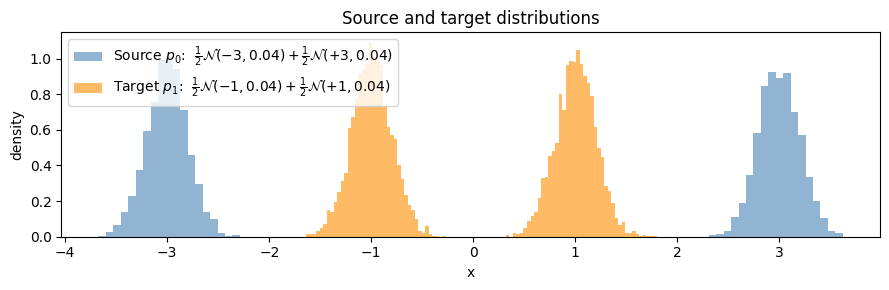

In [2]:
SRC_CENTERS = [-3.0,  3.0]
TGT_CENTERS = [-1.0,  1.0]
STD         =  0.2          # std of every mode (variance = 0.04)


def sample_bimodal(n: int, centers: list) -> torch.Tensor:
    """Equal-weight mixture of two Gaussians, returns shape (n, 1)."""
    component = torch.randint(0, 2, (n,))
    means = torch.where(component == 0,
                        torch.tensor(centers[0]),
                        torch.tensor(centers[1]))
    return (means + STD * torch.randn(n)).unsqueeze(1)


def sample_source(n): return sample_bimodal(n, SRC_CENTERS)
def sample_target(n): return sample_bimodal(n, TGT_CENTERS)


# ── visualise distributions ──────────────────────────────────────────────────
x_src = sample_source(5000).numpy()
x_tgt = sample_target(5000).numpy()

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(x_src, bins=100, density=True, alpha=0.6, color='steelblue',
        label=r'Source $p_0$:  $\frac{1}{2}\mathcal{N}(-3,0.04)+\frac{1}{2}\mathcal{N}(+3,0.04)$')
ax.hist(x_tgt, bins=100, density=True, alpha=0.6, color='darkorange',
        label=r'Target $p_1$:  $\frac{1}{2}\mathcal{N}(-1,0.04)+\frac{1}{2}\mathcal{N}(+1,0.04)$')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Source and target distributions')
plt.tight_layout()
plt.show()

## Why I-CFM creates crossing trajectories — intuition

Consider just two source particles and two target particles:

```
Source: x0_L ≈ -3   x0_R ≈ +3
Target: x1_L ≈ -1   x1_R ≈ +1
```

**I-CFM** (random pairing): with probability ½ the pair $(x_0^L, x_1^R)$ is sampled — the field must point from $-3$ to $+1$. With probability ½ the pair $(x_0^L, x_1^L)$ is sampled — the field must point from $-3$ to $-1$.  
The network averages these and produces a field that points *toward 0*, overshooting both modes.

**OT-CFM** (monotone pairing): in 1D, optimal transport is the *sorted* matching. Left always goes left, right always goes right. The network only ever sees consistent targets and learns a clean, non-crossing field.

Below we train both models and compare side-by-side.

## Shared training infrastructure

In [3]:
DIM        = 1
SIGMA      = 0.01
BATCH_SIZE = 512
N_ITER     = 10000
LR         = 1e-3


def train(use_ot: bool):
    """Train a 1-D flow matching model.
    
    Parameters
    ----------
    use_ot : bool
        If True, use OT coupling (OT-CFM). If False, use independent coupling (I-CFM).
    """
    model     = MLP(dim=DIM, time_varying=True, w=128)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    FM        = ConditionalFlowMatcher(sigma=SIGMA)
    ot_sampler = OTPlanSampler(method='exact') if use_ot else None

    label  = 'OT-CFM' if use_ot else 'I-CFM'
    losses = []
    t0     = time.time()

    for k in range(N_ITER):
        optimizer.zero_grad()

        x0 = sample_source(BATCH_SIZE)
        x1 = sample_target(BATCH_SIZE)

        if use_ot:
            x0, x1 = ot_sampler.sample_plan(x0, x1)

        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

        vt   = model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (k + 1) % 2000 == 0:
            print(f"{label} | iter {k+1:>6d} | loss {loss.item():.4f} | elapsed {time.time()-t0:.1f}s")

    return model, losses

## Train I-CFM

In [4]:
model_icfm, losses_icfm = train(use_ot=False)

I-CFM | iter   2000 | loss 1.6733 | elapsed 13.0s
I-CFM | iter   4000 | loss 1.8524 | elapsed 25.5s
I-CFM | iter   6000 | loss 1.7181 | elapsed 38.2s
I-CFM | iter   8000 | loss 1.6353 | elapsed 50.7s
I-CFM | iter  10000 | loss 1.5709 | elapsed 63.4s


## Train OT-CFM

In [5]:
model_otcfm, losses_otcfm = train(use_ot=True)

OT-CFM | iter   2000 | loss 0.0246 | elapsed 163.4s
OT-CFM | iter   4000 | loss 0.1285 | elapsed 313.8s
OT-CFM | iter   6000 | loss 0.0215 | elapsed 469.9s
OT-CFM | iter   8000 | loss 0.0149 | elapsed 626.1s
OT-CFM | iter  10000 | loss 0.0706 | elapsed 778.5s


## Training loss comparison

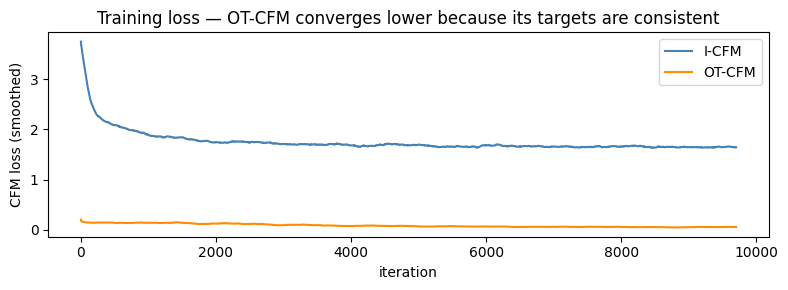

In [6]:
W = 300   # smoothing window

fig, ax = plt.subplots(figsize=(8, 3))
for losses, label, color in [
    (losses_icfm,  'I-CFM',  'steelblue'),
    (losses_otcfm, 'OT-CFM', 'darkorange'),
]:
    smooth = np.convolve(losses, np.ones(W) / W, mode='valid')
    ax.plot(smooth, label=label, color=color)

ax.set_xlabel('iteration')
ax.set_ylabel('CFM loss (smoothed)')
ax.set_title('Training loss — OT-CFM converges lower because its targets are consistent')
ax.legend()
plt.tight_layout()
plt.show()

## ODE integration and trajectory visualisation

We solve $\dot{x} = v_\theta(t, x)$ from $t=0$ to $t=1$ for both models, starting from the same source particles.

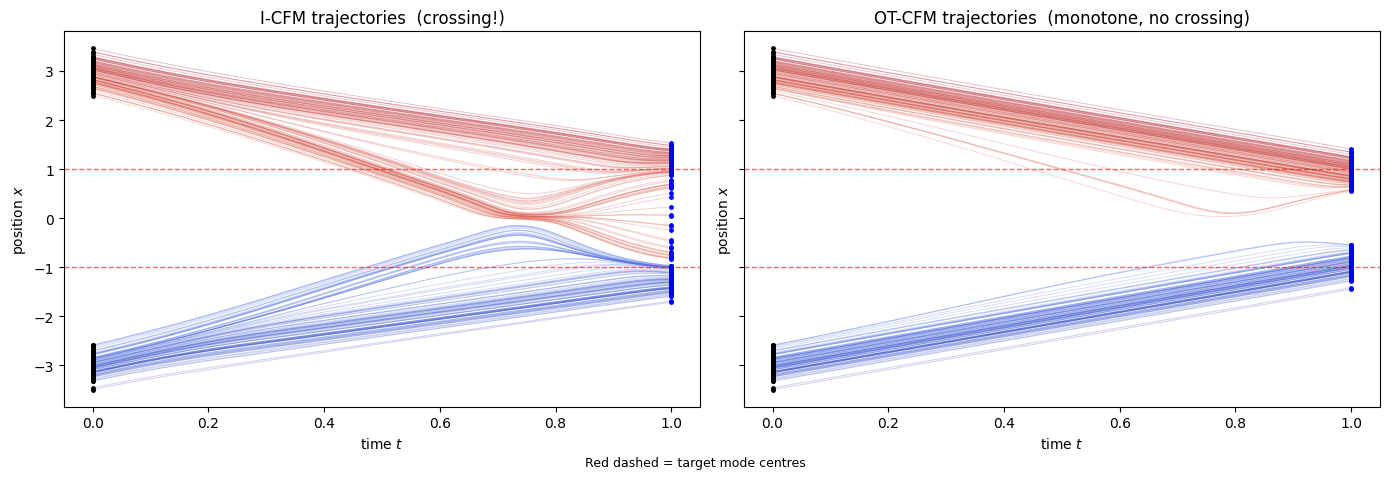

In [7]:
T_SPAN    = torch.linspace(0, 1, 100)
N_TRAJ    = 1000   # particles for integration
N_SHOW    = 200    # particles to draw


def integrate(model, x_init):
    node = NeuralODE(
        torch_wrapper(model),
        solver='dopri5', sensitivity='adjoint', atol=1e-5, rtol=1e-5,
    )
    with torch.no_grad():
        traj = node.trajectory(x_init, t_span=T_SPAN)  # (T, N, 1)
    return traj.cpu().numpy()


x_init   = sample_source(N_TRAJ)
traj_icfm  = integrate(model_icfm,  x_init)   # (100, N, 1)
traj_otcfm = integrate(model_otcfm, x_init)   # (100, N, 1)
t_np = T_SPAN.numpy()


def plot_trajectories(ax, traj, title, show_n=N_SHOW):
    x_start = traj[0, :show_n, 0]
    vmin, vmax = x_start.min(), x_start.max()
    for i in range(show_n):
        c = plt.cm.coolwarm((x_start[i] - vmin) / (vmax - vmin + 1e-8))
        ax.plot(t_np, traj[:, i, 0], color=c, alpha=0.25, linewidth=0.7)
    ax.scatter(np.zeros(show_n), traj[0,  :show_n, 0], s=6, c='black', zorder=3)
    ax.scatter(np.ones(show_n),  traj[-1, :show_n, 0], s=6, c='blue',  zorder=3)
    for c_val in TGT_CENTERS:
        ax.axhline(c_val, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('time $t$')
    ax.set_ylabel('position $x$')
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_trajectories(axes[0], traj_icfm,  'I-CFM trajectories  (crossing!)')
plot_trajectories(axes[1], traj_otcfm, 'OT-CFM trajectories  (monotone, no crossing)')
fig.suptitle('Red dashed = target mode centres', y=0.02, fontsize=9)
plt.tight_layout()
plt.show()

## Generated sample quality

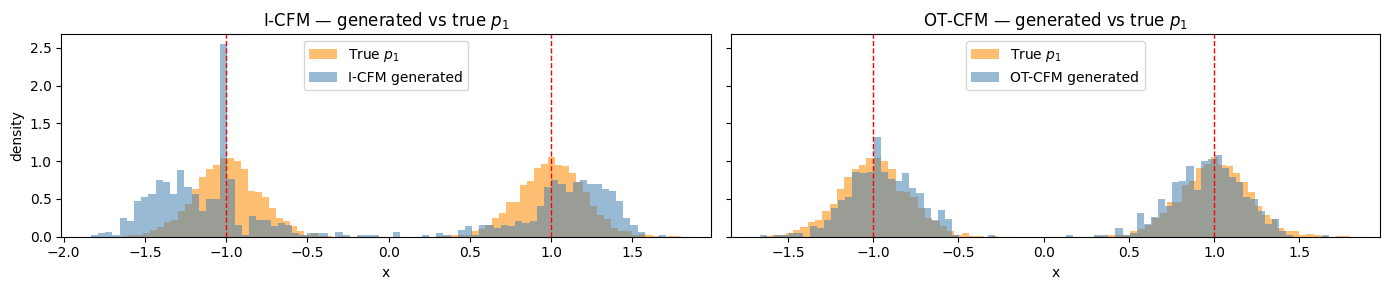

In [8]:
gen_icfm  = traj_icfm[-1,  :, 0]   # final positions
gen_otcfm = traj_otcfm[-1, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
for ax, gen, label in [
    (axes[0], gen_icfm,  'I-CFM'),
    (axes[1], gen_otcfm, 'OT-CFM'),
]:
    ax.hist(x_tgt,              bins=80, density=True, alpha=0.55, color='darkorange', label='True $p_1$')
    ax.hist(gen[:, np.newaxis],  bins=80, density=True, alpha=0.55, color='steelblue',  label=f'{label} generated')
    for c_val in TGT_CENTERS:
        ax.axvline(c_val, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('x')
    ax.set_title(f'{label} — generated vs true $p_1$')
    ax.legend()

axes[0].set_ylabel('density')
plt.tight_layout()
plt.show()

## Learned vector fields — heatmaps

We evaluate $v_\theta(t, x)$ on a fine $(t, x)$ grid for both models.

**What to look for:**
- **I-CFM**: near $x = 0$ and intermediate $t$, the field is nearly zero — it is averaging two opposing directions (left-to-left and left-to-right). The field has to "decide" late which mode to commit to.
- **OT-CFM**: the field is cleanly split at $x = 0$ for all $t$. Left particles always go left, right particles always go right — no cancellation.

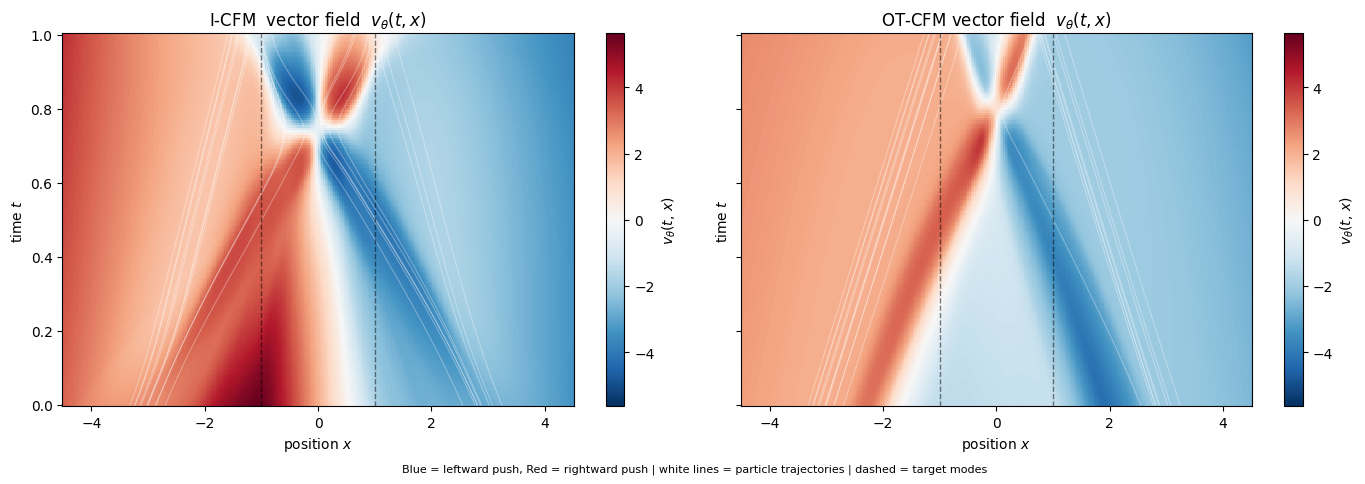

In [9]:
x_grid = np.linspace(-4.5, 4.5, 300)
t_grid = np.linspace(0,    1,   150)
XX, TT = np.meshgrid(x_grid, t_grid)   # (T, X)

x_flat = torch.tensor(XX.ravel(), dtype=torch.float32).unsqueeze(1)
t_flat = torch.tensor(TT.ravel(), dtype=torch.float32).unsqueeze(1)
inp    = torch.cat([x_flat, t_flat], dim=1)


def eval_vf(model):
    model.eval()
    with torch.no_grad():
        return model(inp).numpy().reshape(XX.shape)


VV_icfm  = eval_vf(model_icfm)
VV_otcfm = eval_vf(model_otcfm)

vabs = max(np.abs(VV_icfm).max(), np.abs(VV_otcfm).max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, VV, title in [
    (axes[0], VV_icfm,  'I-CFM  vector field  $v_\\theta(t,x)$'),
    (axes[1], VV_otcfm, 'OT-CFM vector field  $v_\\theta(t,x)$'),
]:
    im = ax.pcolormesh(x_grid, t_grid, VV,
                       cmap='RdBu_r', vmin=-vabs, vmax=vabs, shading='auto')
    plt.colorbar(im, ax=ax, label=r'$v_\theta(t,\,x)$')
    # overlay a few trajectories for context
    traj = traj_icfm if 'I-CFM' in title else traj_otcfm
    for i in range(0, 60, 3):
        ax.plot(traj[:, i, 0], t_np, color='white', alpha=0.35, linewidth=0.7)
    for c_val in TGT_CENTERS:
        ax.axvline(c_val, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('position $x$')
    ax.set_ylabel('time $t$')
    ax.set_title(title)

fig.suptitle('Blue = leftward push, Red = rightward push | white lines = particle trajectories | dashed = target modes',
             y=0.01, fontsize=8)
plt.tight_layout()
plt.show()

## Vector field slices at fixed $t$

Plotting $v_\theta(t, \cdot)$ as a 1-D curve at several time steps makes the difference maximally clear.

**I-CFM**: at early $t$ the field is near zero around $x = 0$ because the network averages opposite-signed contributions from the two pairings. The field only becomes decisive late.

**OT-CFM**: the field is antisymmetric and decisive at **every** $t$ — left of 0 pushes left, right of 0 pushes right. Straight-line dynamics all the way through.

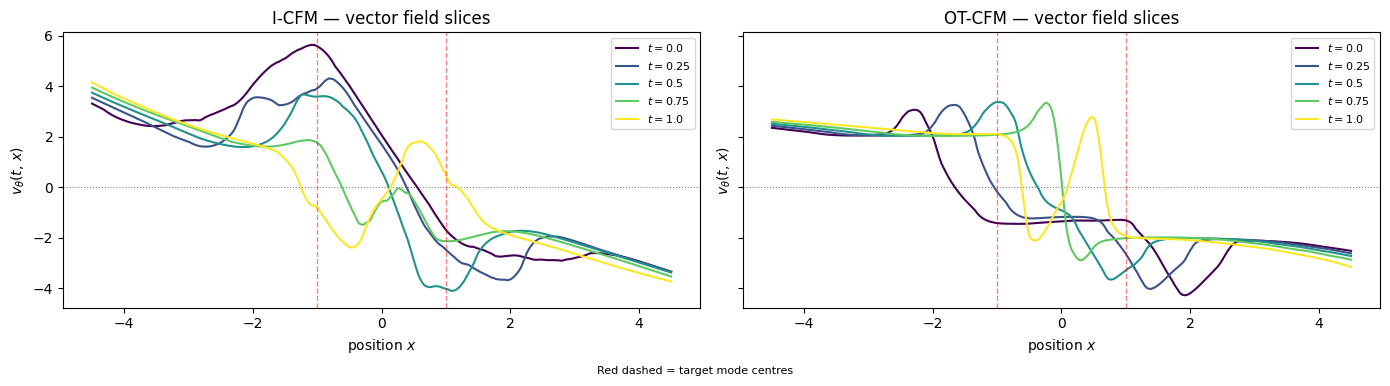

In [10]:
T_SLICES = [0.0, 0.25, 0.5, 0.75, 1.0]
colors   = plt.cm.viridis(np.linspace(0, 1, len(T_SLICES)))
x_line   = torch.linspace(-4.5, 4.5, 500).unsqueeze(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, model, title in [
    (axes[0], model_icfm,  'I-CFM — vector field slices'),
    (axes[1], model_otcfm, 'OT-CFM — vector field slices'),
]:
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    for t_val, col in zip(T_SLICES, colors):
        t_line = torch.full((500, 1), t_val)
        with torch.no_grad():
            v_line = model(torch.cat([x_line, t_line], dim=1)).numpy().ravel()
        ax.plot(x_line.numpy().ravel(), v_line, color=col, label=f'$t={t_val}$')
    for c_val in TGT_CENTERS:
        ax.axvline(c_val, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('position $x$')
    ax.set_ylabel(r'$v_\theta(t,\,x)$')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Red dashed = target mode centres', y=0.01, fontsize=8)
plt.tight_layout()
plt.show()

## Summary

| | I-CFM | OT-CFM |
|---|---|---|
| **Coupling** | random independent | cost-minimising (monotone in 1D) |
| **Trajectories** | crossing, curved | monotone, straight |
| **Vector field** | near-zero "dead zone" at $x\approx0$, late commitment | clean antisymmetry, decisive at all $t$ |
| **Training loss** | higher (conflicting targets) | lower (consistent targets) |
| **Sample quality** | both work, but OT is sharper at the modes | |

The key insight: the CFM loss computes an **expectation over couplings**. Independent coupling injects variance by mixing opposite-direction flows. OT coupling eliminates that variance — the network only ever sees one right answer per $(x_0, t)$ — making the problem easier and the learned field cleaner.